# RBF SVM — Varying C (= 1/λ)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

## 1. Load Data

In [2]:
train = pd.read_csv('train_data.csv')
test = pd.read_csv('test_data.csv')

# Features (x, y coordinates) and labels (0 = blue, 1 = red)
X_train = train[['x', 'y']].values
y_train = (train['label'] == 'red').astype(int).values
X_test = test[['x', 'y']].values
y_test = (test['label'] == 'red').astype(int).values

print(f'Train: {len(X_train)} samples, Test: {len(X_test)} samples')

Train: 23 samples, Test: 21 samples


## 2. Fit RBF SVM for different C values and plot decision boundaries

The RBF (Radial Basis Function) kernel maps data into a higher-dimensional space,
allowing **non-linear** decision boundaries.

- **C = 1/λ**: controls regularization (same as linear case)
- **gamma**: controls how far the influence of a single training point reaches (default = 1 / (n_features * variance))

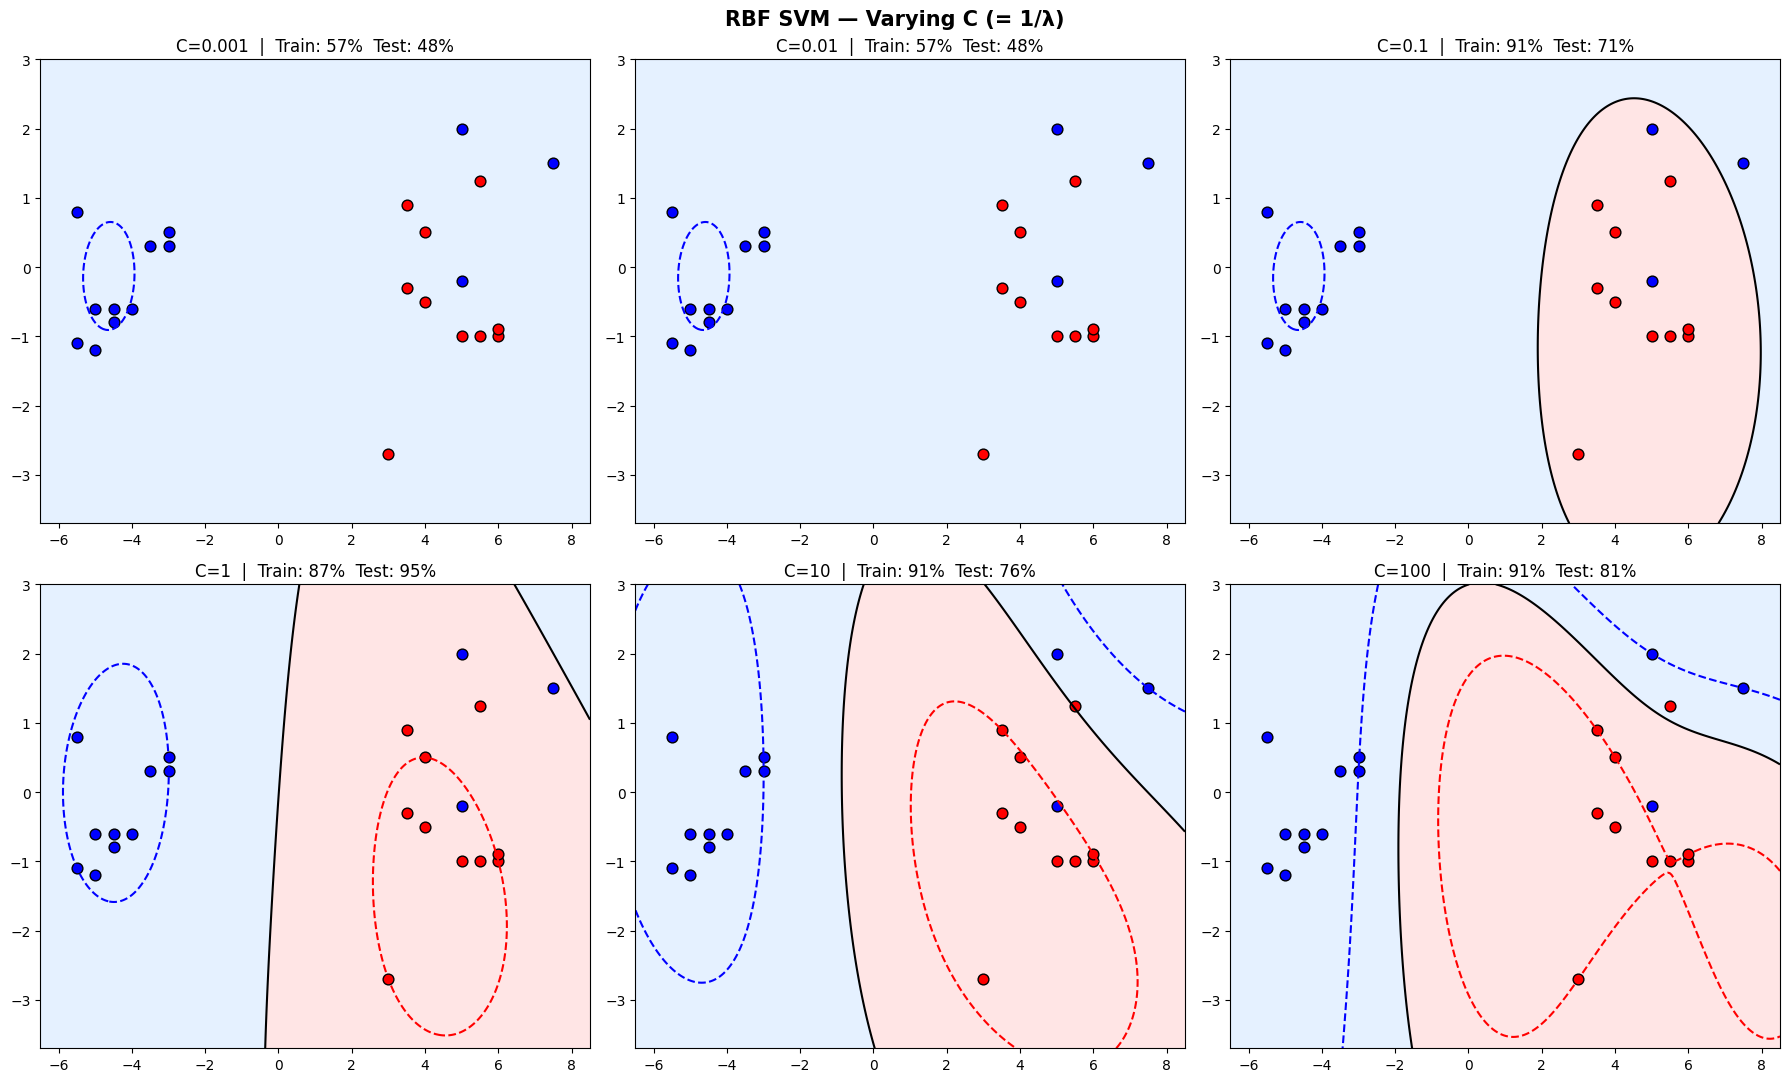

In [3]:
# C values to try
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for i, C in enumerate(C_values):
    ax = axes[i // 3, i % 3]  # pick the right subplot

    # Fit an RBF SVM with this C (gamma='scale' is the default)
    clf = SVC(kernel='rbf', C=C, gamma='scale')
    clf.fit(X_train, y_train)

    # Create a grid of points covering the plot area
    xx, yy = np.meshgrid(
        np.linspace(X_train[:, 0].min() - 1, X_train[:, 0].max() + 1, 300),
        np.linspace(X_train[:, 1].min() - 1, X_train[:, 1].max() + 1, 300)
    )

    # Compute decision function on every grid point
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Plot shaded regions (blue side vs red side)
    ax.contourf(xx, yy, Z, levels=[-1e9, 0, 1e9],
                colors=['#cce5ff', '#ffcccc'], alpha=0.5)

    # Plot decision boundary (0) and margin lines (-1, +1)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1],
               colors=['blue', 'black', 'red'],
               linestyles=['--', '-', '--'])

    # Plot training points
    ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='blue', edgecolors='k', s=60)
    ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='red', edgecolors='k', s=60)

    # Compute accuracies
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))

    ax.set_title(f'C={C}  |  Train: {train_acc:.0%}  Test: {test_acc:.0%}')

plt.suptitle('RBF SVM — Varying C (= 1/λ)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Accuracy Table

In [4]:
print(f"{'C':>8} {'λ=1/C':>8} {'Train':>8} {'Test':>8}")
print('-' * 36)

for C in C_values:
    clf = SVC(kernel='rbf', C=C, gamma='scale').fit(X_train, y_train)
    tr = accuracy_score(y_train, clf.predict(X_train))
    te = accuracy_score(y_test, clf.predict(X_test))
    print(f'{C:>8} {1/C:>8.1f} {tr:>8.0%} {te:>8.0%}')

       C    λ=1/C    Train     Test
------------------------------------
   0.001   1000.0      57%      48%
    0.01    100.0      57%      48%
     0.1     10.0      91%      71%
       1      1.0      87%      95%
      10      0.1      91%      76%
     100      0.0      91%      81%
